# Week 1 — Skills Setup
測試 yfinance 數據抓取、視覺化、4-bit 模型載入

In [1]:
import sys
sys.path.insert(0, '..')
from src.tools.stock_tools import get_stock_history, get_fundamental_data, plot_stock_chart

## Task 1 — 股價歷史資料抓取

In [2]:
df_tsmc = get_stock_history('2330.TW', period='3mo')
print(f'Rows: {len(df_tsmc)}')
df_tsmc.tail()

Rows: 53


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-04-30 00:00:00+08:00,2205.0,2215.0,2135.0,2135.0,48975164,0.0,0.0
2026-05-04 00:00:00+08:00,2200.0,2285.0,2195.0,2275.0,38390062,0.0,0.0
2026-05-05 00:00:00+08:00,2250.0,2270.0,2240.0,2250.0,21625279,0.0,0.0
2026-05-06 00:00:00+08:00,2250.0,2285.0,2240.0,2250.0,31918664,0.0,0.0
2026-05-07 00:00:00+08:00,2335.0,2345.0,2310.0,2315.0,26023976,0.0,0.0


In [3]:
df_etf = get_stock_history('0050.TW', period='3mo')
print(f'Rows: {len(df_etf)}')
df_etf.tail()

Rows: 53


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2026-04-30 00:00:00+08:00,91.250000,91.900002,90.300003,90.500000,82229228,0.0,0.0,0.0
2026-05-04 00:00:00+08:00,92.500000,94.650002,92.400002,94.599998,120393477,0.0,0.0,0.0
2026-05-05 00:00:00+08:00,94.400002,94.750000,94.000000,94.599998,76579608,0.0,0.0,0.0
2026-05-06 00:00:00+08:00,96.050003,96.900002,94.699997,95.750000,105507530,0.0,0.0,0.0
2026-05-07 00:00:00+08:00,97.949997,98.400002,97.400002,97.750000,103435065,0.0,0.0,0.0


## Task 1b — 基本面資料

In [4]:
import json
fundamentals = get_fundamental_data('2330.TW')
print(json.dumps(fundamentals, indent=2, ensure_ascii=False))

{
  "ticker": "2330.TW",
  "name": "Taiwan Semiconductor Manufacturing Company Limited",
  "market_cap": 60032578224128,
  "pe_ratio": 31.462353,
  "dividend_yield": 1.07,
  "52w_high": 2345.0,
  "52w_low": 918.0,
  "current_price": 2315.0
}


## Task 2 — 視覺化

In [5]:
path = plot_stock_chart('2330.TW', df_tsmc)
print(f'Chart saved: {path}')

Chart saved: C:\Data_science\Final\notebooks\..\outputs\charts\2330.TW_20260507_125721.png


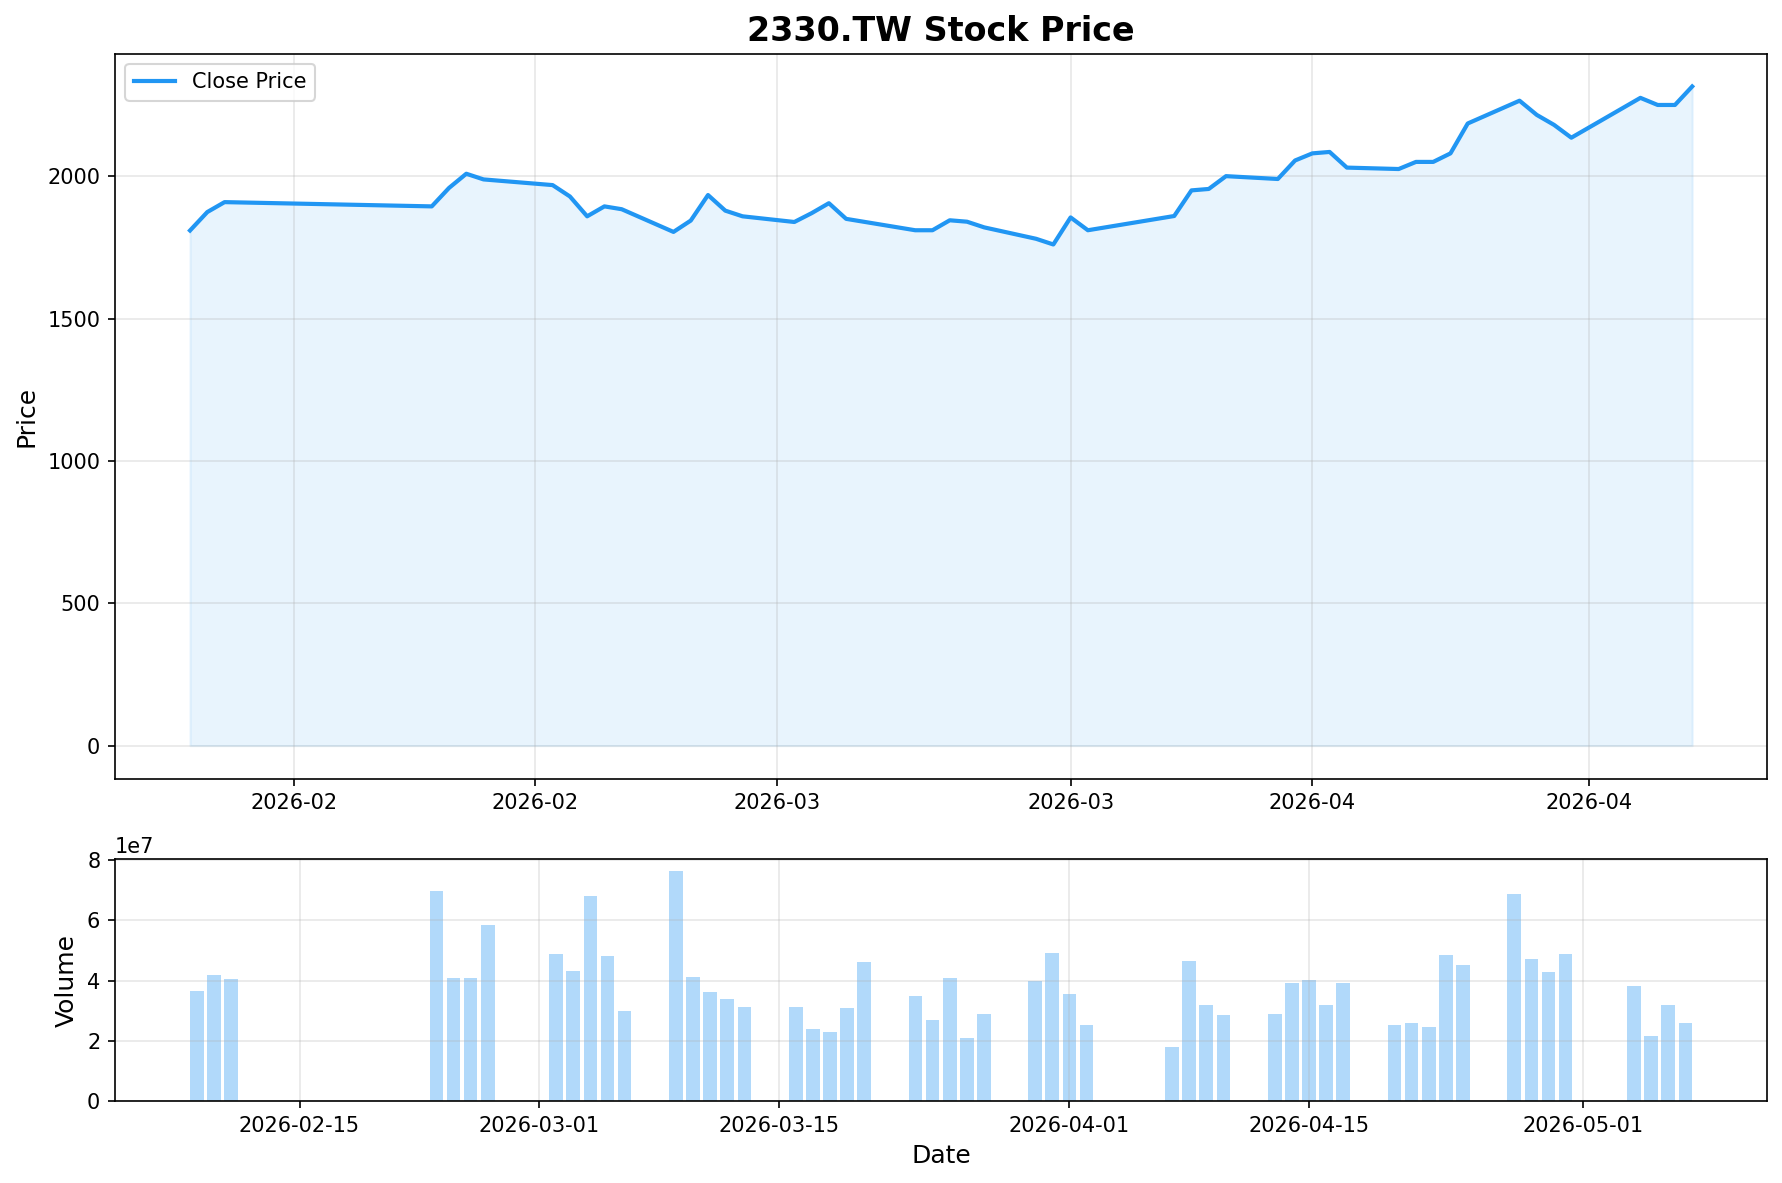

In [6]:
from IPython.display import Image
Image(path)

## Task 3 — 4-bit 模型載入 (需要 GPU)

In [7]:
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB


In [8]:
from src.model import load_model_4bit

tokenizer, model = load_model_4bit()

# Quick inference test
inputs = tokenizer('台積電的主要業務是什麼？', return_tensors='pt').to('cuda')
with torch.no_grad():
    outputs = model.generate(**inputs, max_new_tokens=100)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/291 [00:01<06:41,  1.38s/it]

Loading weights:   1%|          | 2/291 [00:02<06:37,  1.37s/it]

Loading weights:   1%|▏         | 4/291 [00:03<02:54,  1.64it/s]

...

[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Model loaded: meta-llama/Meta-Llama-3-8B-Instruct
Device: cuda:0


[transformers] Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


台積電的主要業務是什麼？What are the main businesses of Taiwan Semiconductor Manufacturing Company (TSMC)?

TSMC is a leading independent semiconductor foundry, which means it manufactures semiconductors designed by other companies, but does not design its own semiconductors. The company's main businesses can be summarized as follows:

1. **Foundry services**: TSMC provides semiconductor manufacturing services to its customers, including the production of integrated circuits (ICs) using various process technologies.
2. **Wafer fabrication
